In [1]:
import numpy as np
import matplotlib.pyplot as plt

<h4>Generacja</h4>

In [2]:
def generate_binary_map(n, density):

    total_pixels = n * n
    num_black_pixels = int(total_pixels * density)

    flat_image = np.concatenate([np.ones(num_black_pixels), 
                                 np.zeros(total_pixels - num_black_pixels)])


    np.random.shuffle(flat_image)

    binary_map = flat_image.reshape((n, n))
    
    return binary_map

In [3]:
def visualize_comparison(map_start, map_end):
    # Создаем фигуру с 1 строкой и 2 колонками
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Отрисовка начальной карты
    axes[0].imshow(map_start, cmap='binary', interpolation='nearest')
    axes[0].set_title("Initial Map", fontsize=15)
    axes[0].axis('off')
    
    # Отрисовка результирующей карты
    axes[1].imshow(map_end, cmap='binary', interpolation='nearest')
    axes[1].set_title("Best Image (Simulated Annealing)", fontsize=15)
    axes[1].axis('off')
    
    # Автоматически подгоняем размеры, чтобы ничего не накладывалось
    plt.tight_layout()
    plt.show()




<h4>Funkcji energii dla 4 sąsiadów<h4>

In [4]:
def energy_islands(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Get 4-neighbors using modulo for periodic boundaries (torus effect)
    neighbors = [
        image[(r - 1) % rows, c], # Top
        image[(r + 1) % rows, c], # Bottom
        image[r, (c - 1) % cols], # Left
        image[r, (c + 1) % cols]  # Right
    ]
    
    energy = 0
    for n in neighbors:
        if n == pixel_color:
            energy -= 1 # Reward for the same color
        else:
            energy += 1 # Penalty for a different color
            
    return energy

# ==========================================
# 2. Anizotropia (Paski / Stripes)
# ==========================================
def energy_anisotropy(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Get neighbors explicitly to distinguish axes
    top = image[(r - 1) % rows, c]
    bottom = image[(r + 1) % rows, c]
    left = image[r, (c - 1) % cols]
    right = image[r, (c + 1) % cols]
    
    energy = 0
    
    # Horizontal axis: Reward same color to form lines
    for n in [left, right]:
        if n == pixel_color:
            energy -= 5 
        else:
            energy += 5
            
    # Vertical axis: Penalize same color to separate the lines
    for n in [top, bottom]:
        if n == pixel_color:
            energy += 5 
        else:
            energy -= 5
            
    return energy

# ==========================================
# 3. Anty-ferromagnetyk (Szachownica / Checkerboard)
# ==========================================
def energy_checkerboard(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    neighbors = [
        image[(r - 1) % rows, c], # Top
        image[(r + 1) % rows, c], # Bottom
        image[r, (c - 1) % cols], # Left
        image[r, (c + 1) % cols]  # Right
    ]
    
    energy = 0
    for n in neighbors:
        if n != pixel_color:
            energy -= 1 # Reward for a DIFFERENT color
        else:
            energy += 1 # Penalty for the SAME color
            
    return energy

# ==========================================
# 4. Idealna ścieżka (Labirynt / Maze)
# ==========================================
def energy_maze(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    neighbors = [
        image[(r - 1) % rows, c], # Top
        image[(r + 1) % rows, c], # Bottom
        image[r, (c - 1) % cols], # Left
        image[r, (c + 1) % cols]  # Right
    ]
    
    # Count how many neighbors share the same color
    same_color_count = sum(1 for n in neighbors if n == pixel_color)
    
    # The pixel "wants" exactly 2 neighbors of the same color to form a path
    if same_color_count == 2:
        return -10 # Strong reward for ideal path configuration
    else:
        return 20  # Strong penalty for endpoints (1), isolated points (0), or thick blobs (3, 4)    for step in range(num_steps):
        # 1. Select random indices from the lists
        b_idx = random.randint(0, len(black_coords) - 1)
        w_idx = random.randint(0, len(white_coords) - 1)
        
        b_r, b_c = black_coords[b_idx]
        w_r, w_c = white_coords[w_idx]

In [5]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt



def temp_exp(iteration, initial_t, par):
    # Returns exponentially decreasing temperature
    return initial_t * (par ** iteration)
def temp_log(iteration, par):
    return 1 / np.log(1 + par * iteration)

def temp_diff(iteration, par):
    return max(0, 1 - par * iteration)



def calculate_total_energy(image, energy_func):

    total_e = 0
    rows, cols = image.shape
    
    for r in range(rows):
        for c in range(cols):
            total_e += energy_func(image, r, c)


    return total_e / 2

def simulated_annealing(initial_image, energy_func, initial_temp, cooling_rate, num_steps):

    current_image = initial_image.copy()
    
    # Pre-calculate lists of coordinates for fast random selection
    # This prevents scanning the entire matrix in every loop iteration
    black_coords = list(map(tuple, np.argwhere(current_image == 1)))
    white_coords = list(map(tuple, np.argwhere(current_image == 0)))
    
    # Initialize variables
    current_temp = initial_temp
    current_total_energy = calculate_total_energy(current_image, energy_func)
    print(current_total_energy)
    
    best_image = current_image.copy()
    best_energy = current_total_energy
    
    # Lists to store the history (as requested)
    energies_history = []
    temps_history = []
    images_history = []
    
    for step in range(num_steps):
        # 1. Select random indices from the lists
        b_idx = random.randint(0, len(black_coords) - 1)
        w_idx = random.randint(0, len(white_coords) - 1)
        
        b_r, b_c = black_coords[b_idx]
        w_r, w_c = white_coords[w_idx]
        
        # 2. Calculate local energy BEFORE the swap
        energy_before = energy_func(current_image, b_r, b_c) + energy_func(current_image, w_r, w_c)
        
        # 3. Perform the swap
        current_image[b_r, b_c] = 0
        current_image[w_r, w_c] = 1
        
        # 4. Calculate local energy AFTER the swap
        energy_after = energy_func(current_image, b_r, b_c) + energy_func(current_image, w_r, w_c)
        
        # 5. Calculate energy difference
        delta_e = energy_after - energy_before
        
        # 6. Acceptance criteria logic
        accept = False
        if delta_e < 0:
            accept = True # Always accept better states
        else:
            # Calculate probability of accepting a worse state
            # Prevent division by zero if temp drops to exactly 0
            if current_temp > 0: 
                probability = math.exp(-delta_e / current_temp)
                if random.random() < probability:
                    accept = True
        
        # 7. Apply or revert changes
        if accept:
            # Update current total energy
            current_total_energy += delta_e
            
            # Update the coordinate lists with the new positions
            black_coords[b_idx] = (w_r, w_c)
            white_coords[w_idx] = (b_r, b_c)
            
            # Check if this is the best state we've seen so far
            if current_total_energy < best_energy:
                best_energy = current_total_energy
                best_image = current_image.copy()
        else:
            # Revert the swap on the image canvas
            current_image[b_r, b_c] = 1
            current_image[w_r, w_c] = 0
            
        # 8. Log the history
        energies_history.append(current_total_energy)
        temps_history.append(current_temp)
        
        # Save a copy of the image every 50 steps
        if step % 50 == 0:
            images_history.append(current_image.copy())
            
        # 9. Cool down the system
        current_temp = temp_exp(step, initial_temp, cooling_rate)
        
    return best_image, best_energy, energies_history, temps_history, images_history

size = 200
density = 0.3
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_islands, 
    initial_temp=100.0, 
    cooling_rate=0.999, 
    num_steps=600000
)



-13076.0


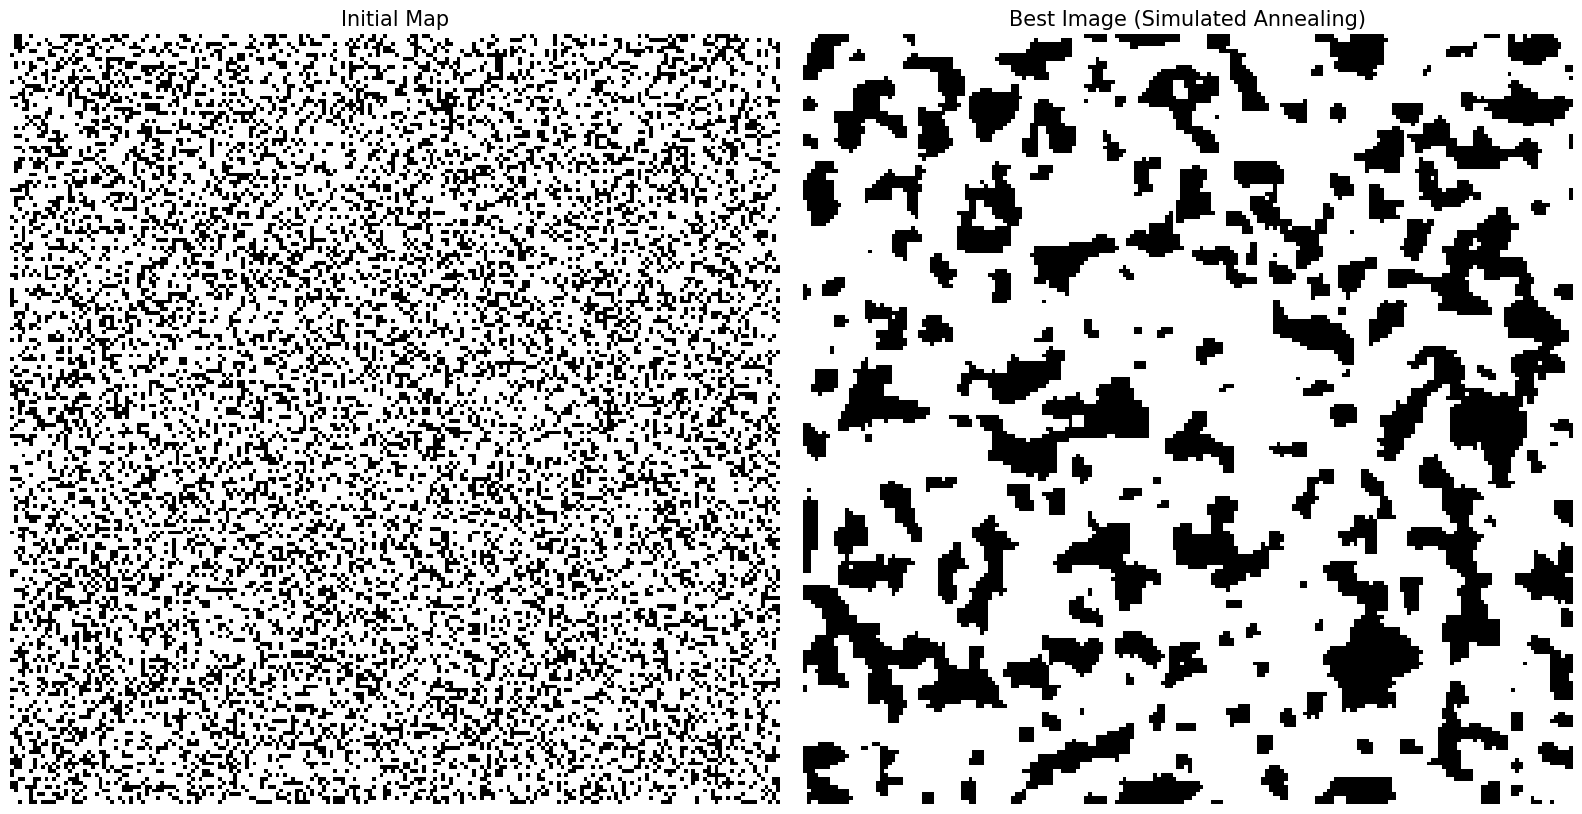

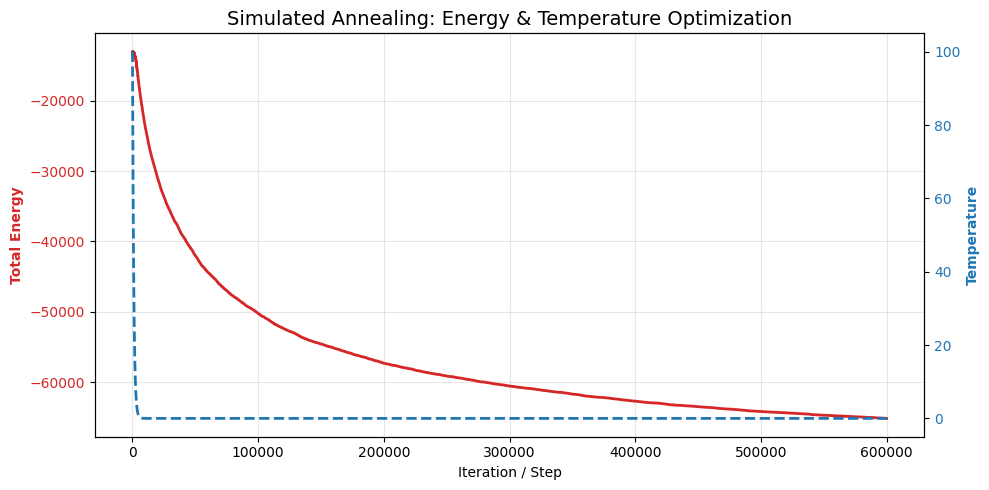

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==========================================
# 1. Visualization of Energy and Temperature
# ==========================================
def plot_energy_and_temp(energies, temps):
    """
    Plots the history of total energy and temperature on a single chart
    using dual Y-axes.
    """
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # --- Left Y-Axis: Total Energy ---
    color_energy = 'tab:red'
    ax1.set_xlabel('Iteration / Step')
    ax1.set_ylabel('Total Energy', color=color_energy, fontweight='bold')
    # Plot the energy history line
    ax1.plot(energies, color=color_energy, label='Energy', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_energy)
    ax1.grid(True, alpha=0.3)

    # --- Right Y-Axis: Temperature ---
    # Create a twin axis sharing the same X-axis
    ax2 = ax1.twinx()  
    color_temp = 'tab:blue'
    ax2.set_ylabel('Temperature', color=color_temp, fontweight='bold')
    # Plot the temperature history line (dashed)
    ax2.plot(temps, color=color_temp, linestyle='--', label='Temperature', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color_temp)

    # --- Final Layout Adjustments ---
    plt.title('Simulated Annealing: Energy & Temperature Optimization', fontsize=14)
    fig.tight_layout() # Ensures labels don't get cut off
    plt.show()

# ==========================================
# 2. GIF Generation from Image History
# ==========================================
def generate_annealing_gif(images_history, filename="annealing.gif", save_interval=50):
    """
    Creates an animated GIF from a list of numpy array images.
    
    :param images_history: List of 2D numpy arrays representing the grid over time.
    :param filename: Name of the output file (must end with .gif).
    :param fps: Frames per second for the animation.
    :param save_interval: The step interval used when saving images (used for the title).
    """
    print("Generating GIF, please wait...")
    
    # Create a figure without axes for a clean look
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis('off')

    # Render the first frame to initialize the plot
    im = ax.imshow(images_history[0], cmap='binary', interpolation='nearest')
    title = ax.set_title("Iteration: 0", fontsize=14)

    # This function is called for every frame in the animation
    def update(frame_idx):
        # Update the image data
        im.set_array(images_history[frame_idx])
        # Update the title to reflect the correct iteration number
        title.set_text(f"Iteration: {frame_idx * save_interval}")
        return [im, title]

    # Create the animation object
    ani = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(images_history), 
        blit=True # Blitting optimizes the rendering process
    )

    # Save the animation using PillowWriter (standard in matplotlib for GIFs)
    writer = animation.PillowWriter()
    ani.save(filename, writer=writer)
    
    # Close the figure so it doesn't display as a static plot below the code
    plt.close() 
    
    print(f"Success! GIF saved as: {filename}")

visualize_comparison(initial_map, best_img)
plot_energy_and_temp(energies, temps)
#generate_annealing_gif(history, filename="annealing_wynik.gif", save_interval=50)

<h4>Funkcji dla 8-sąsiedstwa</h4>

In [17]:
import numpy as np

# ==========================================
# 3. Realizm fizyczny (Distance-based weights)
# ==========================================
def energy_physical_realism(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Direct neighbors (distance = 1)
    straights = [
        image[(r - 1) % rows, c], # Top
        image[(r + 1) % rows, c], # Bottom
        image[r, (c - 1) % cols], # Left
        image[r, (c + 1) % cols]  # Right
    ]
    
    # Diagonal neighbors (distance ≈ 1.41)
    diagonals = [
        image[(r - 1) % rows, (c - 1) % cols], # Top-Left
        image[(r - 1) % rows, (c + 1) % cols], # Top-Right
        image[(r + 1) % rows, (c - 1) % cols], # Bottom-Left
        image[(r + 1) % rows, (c + 1) % cols]  # Bottom-Right
    ]
    
    energy = 0
    
    # Stronger interaction for closer neighbors
    for n in straights:
        if n == pixel_color:
            energy -= 2
        else:
            energy += 2
            
    # Weaker interaction for further (diagonal) neighbors
    for n in diagonals:
        if n == pixel_color:
            energy -= 1
        else:
            energy += 1
            
    return energy

# ==========================================
# 4. Paski ukośne / Padający deszcz (Diagonal anisotropy)
# ==========================================
def energy_diagonal_rain(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # "Good" direction for our stripes (Top-Left to Bottom-Right)
    good_diags = [
        image[(r - 1) % rows, (c - 1) % cols], # Top-Left
        image[(r + 1) % rows, (c + 1) % cols]  # Bottom-Right
    ]
    
    # "Bad" direction that breaks the stripes (Top-Right to Bottom-Left)
    bad_diags = [
        image[(r - 1) % rows, (c + 1) % cols], # Top-Right
        image[(r + 1) % rows, (c - 1) % cols]  # Bottom-Left
    ]
    
    # Notice we completely ignore straight neighbors (they add 0 energy)
    energy = 0
    
    # Reward same color along the good diagonal
    for n in good_diags:
        if n == pixel_color:
            energy -= 2
        else:
            energy += 2
            
    # Penalize same color along the crossing diagonal
    for n in bad_diags:
        if n == pixel_color:
            energy += 2
        else:
            energy -= 2
            
    return energy

# ==========================================
# 5. Piana / Sieć komórkowa (Optimal counting)
# ==========================================
def energy_foam(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Gather all 8 neighbors
    neighbors = [
        image[(r - 1) % rows, c],               # Top
        image[(r + 1) % rows, c],               # Bottom
        image[r, (c - 1) % cols],               # Left
        image[r, (c + 1) % cols],               # Right
        image[(r - 1) % rows, (c - 1) % cols],  # Top-Left
        image[(r - 1) % rows, (c + 1) % cols],  # Top-Right
        image[(r + 1) % rows, (c - 1) % cols],  # Bottom-Left
        image[(r + 1) % rows, (c + 1) % cols]   # Bottom-Right
    ]
    
    # Count how many neighbors share the same color
    same_color_count = sum(1 for n in neighbors if n == pixel_color)
    
    # Apply energy rules based on the specific count
    if same_color_count <= 2:
        # Strong penalty for isolated pixels or dead ends
        return 10
    elif same_color_count in [3, 4, 5]:
        # Reward for forming thin walls, loops and webs
        return -5
    elif same_color_count == 8:
        # Strong penalty for forming thick, solid blobs
        return 10
    else:
        # Neutral state for 6 or 7 neighbors (transition zones)
        return 0
    
def energy_pentagonal(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Pentagon facing UP (includes Left, Right, Top-Left, Top, Top-Right)
    pentagon_neighbors = [
        image[r, (c - 1) % cols],              # Left
        image[r, (c + 1) % cols],              # Right
        image[(r - 1) % rows, (c - 1) % cols], # Top-Left
        image[(r - 1) % rows, c],              # Top
        image[(r - 1) % rows, (c + 1) % cols]  # Top-Right
    ]
    
    # The excluded bottom row (Bottom-Left, Bottom, Bottom-Right)
    excluded_neighbors = [
        image[(r + 1) % rows, (c - 1) % cols], # Bottom-Left
        image[(r + 1) % rows, c],              # Bottom
        image[(r + 1) % rows, (c + 1) % cols]  # Bottom-Right
    ]
    
    energy = 0
    
    # Reward same color inside the pentagonal shape (directional attraction)
    for n in pentagon_neighbors:
        if n == pixel_color:
            energy -= 2
        else:
            energy += 2
            
    # Penalize same color in the excluded region (directional repulsion)
    for n in excluded_neighbors:
        if n == pixel_color:
            energy += 2
        else:
            energy -= 2
            
    return energy

def energy_snake(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    # Direct cross neighbors (Top, Bottom, Left, Right)
    direct_neighbors = [
        image[(r - 1) % rows, c], # Top
        image[(r + 1) % rows, c], # Bottom
        image[r, (c - 1) % cols], # Left
        image[r, (c + 1) % cols]  # Right
    ]
    
    # Diagonal neighbors
    diagonal_neighbors = [
        image[(r - 1) % rows, (c - 1) % cols], # Top-Left
        image[(r - 1) % rows, (c + 1) % cols], # Top-Right
        image[(r + 1) % rows, (c - 1) % cols], # Bottom-Left
        image[(r + 1) % rows, (c + 1) % cols]  # Bottom-Right
    ]
    
    energy = 0
    
    # Count how many direct neighbors share the same color
    same_direct = sum(1 for n in direct_neighbors if n == pixel_color)
    
    # Enforce the "Snake" topology (lines of 1 pixel width)
    if same_direct == 2:
        # Ideal state: exactly 2 neighbors means continuous line
        energy -= 6 
    elif same_direct == 1:
        # Acceptable state: line ending (head/tail of the snake)
        energy -= 2 
    else:
        # Bad state: 0 means isolated dot, 3 or 4 means a thick blob/cross
        energy += 8 
        
    # Penalize diagonal connections to prevent the snake from becoming thick
    # and forming 2x2 blocks of the same color
    for n in diagonal_neighbors:
        if n == pixel_color:
            energy += 3
        else:
            energy -= 1
            
    return energy

def energy_massive_islands(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    # 5x5 neighborhood (radius of 2 pixels)
    for i in range(-4, 4):
        for j in range(-4, 4):
            # Skip the center pixel itself
            if i == 0 and j == 0:
                continue
                
            n_r = (r + i) % rows
            n_c = (c + j) % cols
            
            # Distance: 1 for immediate neighbors, 2 for the outer ring
            distance = max(abs(i), abs(j)) 
            
            # Weight: 2 for distance 1, 1 for distance 2
            weight = 3 - distance 
            
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                energy += weight
                
    return energy

def energy_snake_grid(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    # 13x13 window (from -6 to +6)
    for dx in range(-6, 7):
        for dy in range(-6, 7):
            # Skip the center pixel itself
            if dx == 0 and dy == 0:
                continue
                
            # The original logic defining the grid/cross pattern
            if (dx % 3 == 0 and abs(dy) <= 1) or (dy % 3 == 0 and abs(dx) <= 1):
                weight = 3  # Strong attraction on the grid lines
            else:
                weight = -1 # Repulsion in the empty spaces
                
            # Wrap around edges (periodic boundaries)
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            # If colors match, subtract weight (good things lower energy)
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                # If colors differ, add weight
                energy += weight
                
    return energy

100388.0


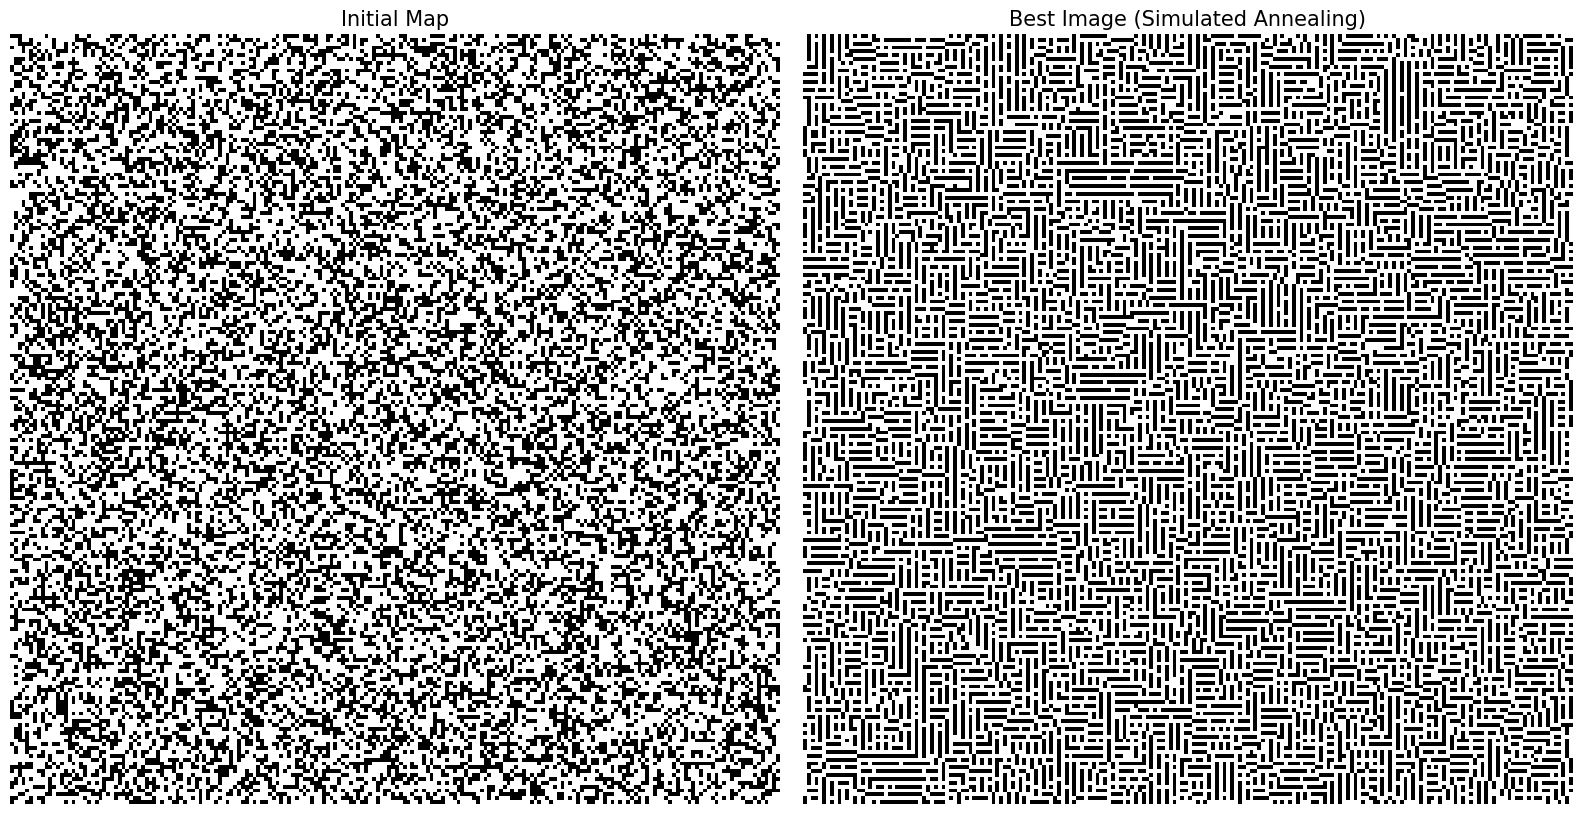

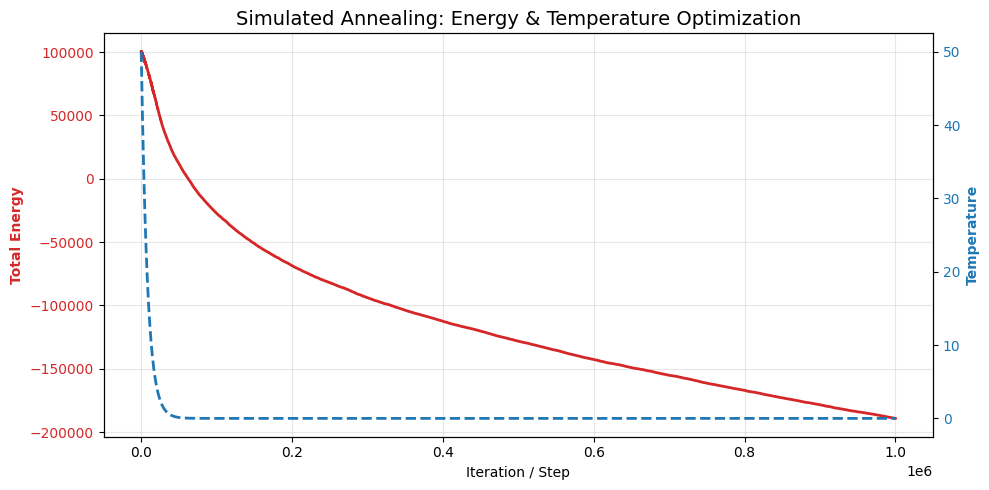

In [ ]:

size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_snake, 
    initial_temp=500.0, 
    cooling_rate=0.99988, 
    num_steps=1000000
)
visualize_comparison(initial_map, best_img)
plot_energy_and_temp(energies, temps)

In [32]:
def energy_foa2(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    
    same_color_count = 0
    
    # Count ALL same-colored neighbors in the 8-16 neighborhood (5x5)
    for dx in range(-2, 3):
        for dy in range(-2, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            if image[n_r, n_c] == pixel_color:
                same_color_count += 1
                
    # Non-linear energy function
    # The ideal number of same-colored neighbors is exactly 7 (out of 24)
    target_neighbors = 7
    
    # Energy is the absolute distance from the ideal state
    # If count is 7, energy is 0 (perfect!). If count is 24, energy is huge (terrible!)
    energy = abs(same_color_count - target_neighbors) * 2
    
    return energy

def energy_fingerprint(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    # 5x5 window (8-16 neighborhood)
    for dx in range(-2, 3):
        for dy in range(-2, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            # Anisotropy: Horizontal-ish lines attract, Vertical-ish lines repel
            # We use absolute distance to determine orientation
            if abs(dy) > abs(dx):
                weight = 2   # Strong horizontal attraction
            elif abs(dx) > abs(dy):
                weight = -2  # Strong vertical repulsion
            else:
                weight = 0   # Neutrals on exact diagonals
                
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                energy += weight
                
    return energy

def energy_quantum_dots(image, r, c):
    rows, cols = image.shape
    pixel_color = image[r, c]
    energy = 0
    
    for dx in range(-2, 3):
        for dy in range(-2, 3):
            if dx == 0 and dy == 0:
                continue
                
            n_r = (r + dx) % rows
            n_c = (c + dy) % cols
            
            # Distance 1 means inner ring (8 neighbors)
            # Distance 2 means outer ring (16 neighbors)
            distance = max(abs(dx), abs(dy))
            
            if distance == 1:
                weight = -4 # HUGE repulsion for immediate contact
            elif distance == 2:
                weight = 1  # Mild attraction at a distance
                
            if image[n_r, n_c] == pixel_color:
                energy -= weight
            else:
                energy += weight
                
    return energy

12772.0


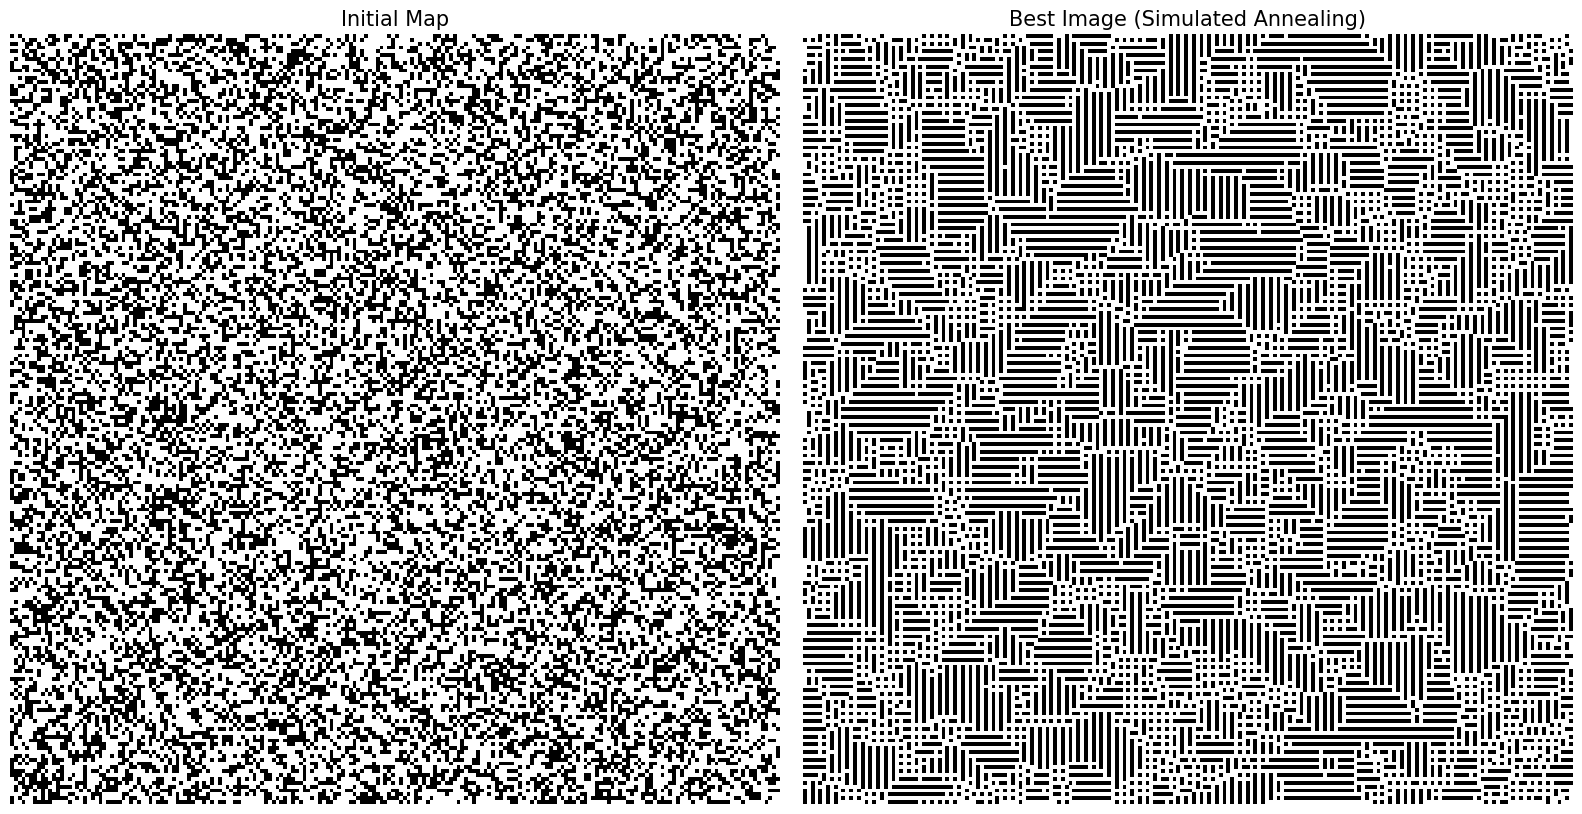

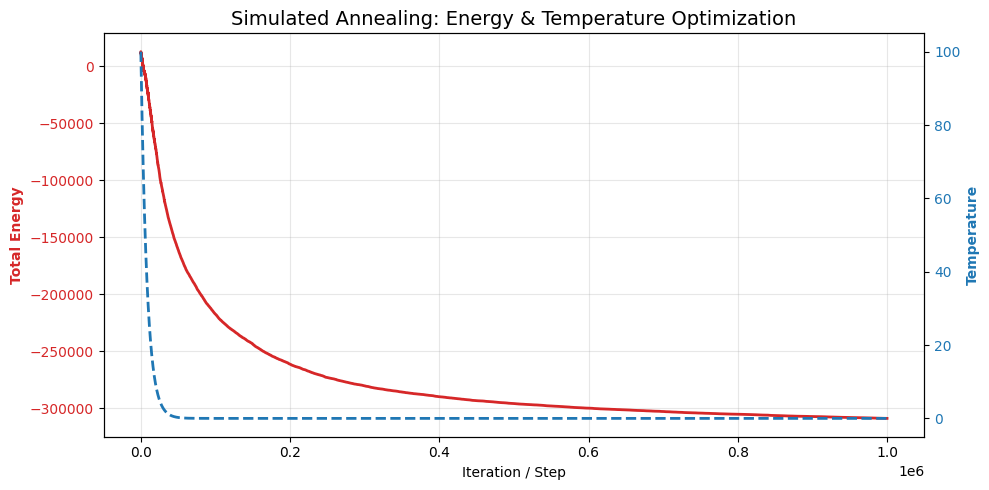

In [38]:
size = 200
density = 0.4
initial_map = generate_binary_map(size, density)

best_img, best_e, energies, temps, history = simulated_annealing(
    initial_image=initial_map, 
    energy_func=energy_quantum_dots, 
    initial_temp=100.0, 
    cooling_rate=0.99988, 
    num_steps=1000000
)
visualize_comparison(initial_map, best_img)
plot_energy_and_temp(energies, temps)